## Eval ppl on holdout data for different models at the AA level

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

In [ ]:
samples_dir = "results/inf_eval"
peint_df = pd.read_csv(f"{samples_dir}/peint_model_d4.csv")
codon_df = pd.read_csv(f"{samples_dir}/codon_model_aa_vocab_dx.csv")
ctmc_df = pd.read_csv(f"{samples_dir}/ctmc_model_d4.csv")
# dasm_opt_bl_df = pd.read_csv(f"{samples_dir}/dasm_opt_bls_d4.csv")
dasm_og_bl_df = pd.read_csv(f"{samples_dir}/dasm_orig_bls_dx.csv")

/tmp/ipykernel_3162302/631557098.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='model', y='perplexity', order=order, palette=palette, ax=ax, showmeans=False)


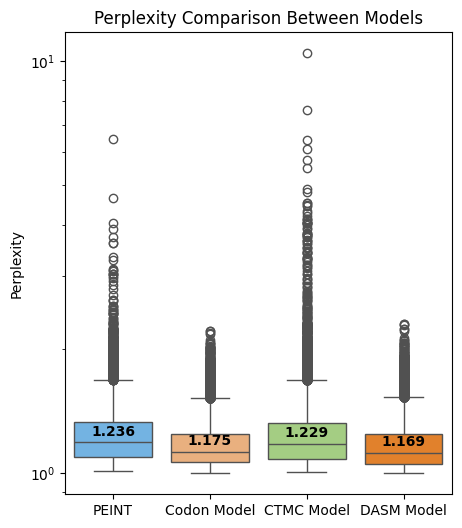

In [47]:
# whisker plot perplexity column. color by method and annotate mean above each box
combined = pd.concat([
    peint_df.assign(model='PEINT'),
    ctmc_df.assign(model='CTMC Model'),
    codon_df.assign(model='Codon Model'),
    dasm_og_bl_df.assign(model='DASM Model'),
], ignore_index=True)

order = ['PEINT', 'Codon Model', 'CTMC Model', 'DASM Model']
palette = {'PEINT': "#60b6f4", 'Codon Model': "#fbaf6d", 'CTMC Model': "#a3d977", 'DASM Model': "#ff7f0e"}

fig, ax = plt.subplots(figsize=(5, 6))
sns.boxplot(data=combined, x='model', y='perplexity', order=order, palette=palette, ax=ax, showmeans=False)
ax.set_title('Perplexity Comparison Between Models')
ax.set_xlabel('')
ax.set_ylabel('Perplexity')
ax.set_yscale('log')

# compute means and annotate
means = combined.groupby('model')['perplexity'].mean()
for i, m in enumerate(order):
    mean_val = means.loc[m]
    y = mean_val * 0.98
    ax.text(i, y, f"{mean_val:.3f}", ha='center', va='bottom', fontweight='bold')

plt.show()

/tmp/ipykernel_3162302/758342829.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)


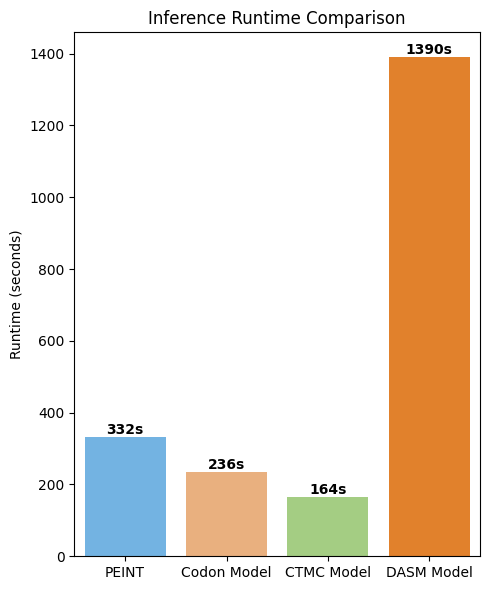

In [48]:
runtime_in_seconds = {
    "PEINT": 5*60+32,
    "Codon Model": 180+56,
    "CTMC Model": 120+44,
    "DASM Model": 1390
}
order = ['PEINT', 'Codon Model', 'CTMC Model', 'DASM Model']
palette = {'PEINT': "#60b6f4", 'Codon Model': "#fbaf6d", 'CTMC Model': "#a3d977", 'DASM Model': "#ff7f0e"}

# Create runtime comparison plot
runtime_df = pd.DataFrame(list(runtime_in_seconds.items()), columns=['model', 'runtime'])

fig, ax = plt.subplots(figsize=(5, 6))
sns.barplot(data=runtime_df, x='model', y='runtime', order=order, palette=palette, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Inference Runtime Comparison')

# Annotate bars with values
for i, m in enumerate(order):
    runtime_val = runtime_in_seconds[m]
    ax.text(i, runtime_val, f"{runtime_val}s", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
